In [7]:
#loading and preprocessing

#importing modules
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

#each image is of 32x32 pixels (wdith and height) size 
#batch=number of images processed together in one forward/backward pass during training
#data dir is directory containing the dataset
#all are constants, hence uppercase
IMG_SIZE=32
BATCH=64
DATA_DIR="./DevanagariHandwrittenCharacterDataset"


#transform: convert to 1-channel gryascale type and resize to be on safe side
transform=transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(), #convert to tensor, i.e. normalizing each pixel value from 0-255 to 0.0 to 1.0
])

full_train=datasets.ImageFolder(f"{DATA_DIR}/Train", transform=transform)
test_set=datasets.ImageFolder(f"{DATA_DIR}/Test", transform=transform)

class_names=full_train.classes #list of all folder names
num_classes=len(class_names)

# print(class_names)
# print(num_classes)

n_val=int(0.2*len(full_train)) #hold 20% as validation
n_train=len(full_train)-n_val
train_set,val_set=random_split(full_train, [n_train, n_val], generator=torch.Generator().manual_seed(123))

#DataLoaders feed batches to the model. num_worker is for parallelizing disk reading.
train_loader=DataLoader(train_set, batch_size=BATCH, shuffle=True, num_workers=4)
val_loader=DataLoader(val_set, batch_size=BATCH, shuffle=False, num_workers=4)
test_loader=DataLoader(test_set, batch_size=BATCH, shuffle=True, num_workers=4)

#shuffle=True randomizes sample each epoch


In [11]:
#building the CNN (not the news channel one)

import torch.nn as nn
import torch.nn.functional as F

class DevanagariCNN(nn.Module):
    def __init__(self,num_classes):
        super().__init__()

        #Conv block1: 1 input channel to 32 feature maps
        self.conv1=nn.Conv2d(1,32, kernel_size=3, padding=1)
        self.bn1=nn.BatchNorm2d(32)

        #Conv block2: 32 to 64
        self.conv2=nn.Conv2d(32,64,kernel_size=3, padding=1)
        self.bn2= nn.BatchNorm2d(64)

        #Conv block3:64 to 128
        self.conv3=nn.Conv2d(64,128,kernel_size=3, padding=1)
        self.bn3=nn.BatchNorm2d(128)
        
        self.pool=nn.MaxPool2d(2,2) #halves height and width each time

        #after 3 poolings: 32 to 16 to 8 to 4, so feature map is 128x4x4
        self.fc1=nn.Linear(128*4*4,256)
        self.dropout=nn.Dropout(0.5)
        self.fc2=nn.Linear(256,num_classes)

    def forward(self,x):
        x=self.pool(F.relu(self.bn1(self.conv1(x)))) #32 to 16
        x=self.pool(F.relu(self.bn2(self.conv2(x))))# 16 to 8
        x=self.pool(F.relu(self.bn3(self.conv3(x)))) #8 to 4
        x=torch.flatten(x,1)
        x=F.relu(self.fc1(x))
        x=self.dropout(x)
        x=self.fc2(x) 

        return x

device=torch.device("cuda")
model=DevanagariCNN(num_classes).to(device)
print(model)


DevanagariCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=46, bias=True)
)


In [12]:
#training step

import torch.optim as optim

criterion = nn.CrossEntropyLoss()  # loss for integer labels
optimizer = optim.Adam(model.parameters(), lr=0.001)   # Adam optimizer

EPOCHS = 20
best_val_acc = 0.0
history = {"train_acc": [], "val_acc": []}

for epoch in range(EPOCHS):
    #Training phase
    model.train()  # enabling dropout and batchnorm updates
    correct, total = 0,0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device) # move to GPU

        optimizer.zero_grad()          # clear gradients from previous step
        outputs = model(images)        # forward pass
        loss = criterion(outputs, labels)
        loss.backward()                # backpropagation: compute gradients
        optimizer.step()               # update weights

        correct+= (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    train_acc = correct / total

    #Validation phase
    model.eval()     # disables dropout, freezes batchnorm
    correct, total = 0, 0
    with torch.no_grad(): # no gradient tracking = faster, less memory
        for images, labels in val_loader:
            images, labels= images.to(device), labels.to(device)
            outputs= model(images)
            correct+= (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    val_acc = correct / total

    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    print(f"Epoch {epoch+1}/{EPOCHS}  train_acc={train_acc:.4f}  val_acc={val_acc:.4f}")

    # Save the best model so far
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")

print(f"Best validation accuracy: {best_val_acc:.4f}")


Epoch 1/20  train_acc=0.7170  val_acc=0.9538
Epoch 2/20  train_acc=0.8826  val_acc=0.9592
Epoch 3/20  train_acc=0.9078  val_acc=0.9593
Epoch 4/20  train_acc=0.9221  val_acc=0.9733
Epoch 5/20  train_acc=0.9318  val_acc=0.9779
Epoch 6/20  train_acc=0.9408  val_acc=0.9820
Epoch 7/20  train_acc=0.9465  val_acc=0.9834
Epoch 8/20  train_acc=0.9511  val_acc=0.9824
Epoch 9/20  train_acc=0.9569  val_acc=0.9820
Epoch 10/20  train_acc=0.9599  val_acc=0.9846
Epoch 11/20  train_acc=0.9635  val_acc=0.9824
Epoch 12/20  train_acc=0.9666  val_acc=0.9873
Epoch 13/20  train_acc=0.9699  val_acc=0.9870
Epoch 14/20  train_acc=0.9713  val_acc=0.9842
Epoch 15/20  train_acc=0.9740  val_acc=0.9850
Epoch 16/20  train_acc=0.9753  val_acc=0.9882
Epoch 17/20  train_acc=0.9764  val_acc=0.9872
Epoch 18/20  train_acc=0.9787  val_acc=0.9856
Epoch 19/20  train_acc=0.9785  val_acc=0.9874
Epoch 20/20  train_acc=0.9809  val_acc=0.9884
Best validation accuracy: 0.9884


Test accuracy: 0.9881
                           precision    recall  f1-score   support

         character_10_yna       0.99      0.99      0.99       300
    character_11_taamatar       1.00      0.97      0.98       300
        character_12_thaa       0.99      1.00      0.99       300
         character_13_daa       0.98      0.99      0.99       300
        character_14_dhaa       0.99      0.98      0.98       300
        character_15_adna       1.00      0.99      0.99       300
      character_16_tabala       0.98      1.00      0.99       300
         character_17_tha       0.96      0.99      0.97       300
          character_18_da       0.96      0.98      0.97       300
         character_19_dha       1.00      0.96      0.98       300
           character_1_ka       1.00      1.00      1.00       300
          character_20_na       1.00      0.99      0.99       300
          character_21_pa       0.98      0.99      0.98       300
         character_22_pha       1.00   

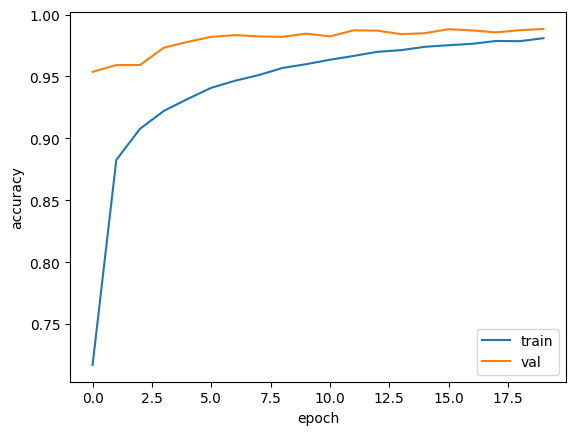

In [ ]:
#evaluation

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

#Loading best weights
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images= images.to(device)
        outputs= model(images)
        preds= outputs.argmax(1).cpu().numpy()  # bring back to CPU for numpy
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds= np.array(all_preds)
all_labels= np.array(all_labels)

test_acc = (all_preds == all_labels).mean()
print(f"Test accuracy: {test_acc:.4f}")

# Per-class precision / recall / F1
print(classification_report(all_labels, all_preds, target_names=class_names))

#Training curves (shows overfitting visually)
plt.plot(history["train_acc"], label="train")
plt.plot(history["val_acc"], label="val")
plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend(); plt.show()